In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from google.colab import files
files.upload()

Saving netflix_customer_churn.csv to netflix_customer_churn.csv


{'netflix_customer_churn.csv': b'customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre\na9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action\n49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.7,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi\n4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama\nd3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror\n4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action\nd8079475-5be7-47e9-8782-ceb7ff61395e,58,Female,Standard,13.8,26,Oceania,Mobile,13.99,0,Debit Card,3,0.51,Action\n8e63450a-13d6-4e83-bbb5-6aebde9152cb,48,Other,Basic,13.83,20,Asia,TV,8.99,0,Gift Card,5,0.66,Romance\n02387681-8c42-462a-807a-de0168c73b38,51,Male,Basic,1

In [ ]:
df = pd.read_csv('netflix_customer_churn.csv')
df.columns = df.columns.str.strip()

df['avg_watch_time_per_day'] = pd.to_numeric(df['avg_watch_time_per_day'], errors='coerce')
df.loc[df['avg_watch_time_per_day'] > 10, 'avg_watch_time_per_day'] /= 10

# Binary target
df['Churn_bin'] = df['churned']

No missing values found in the DataFrame.


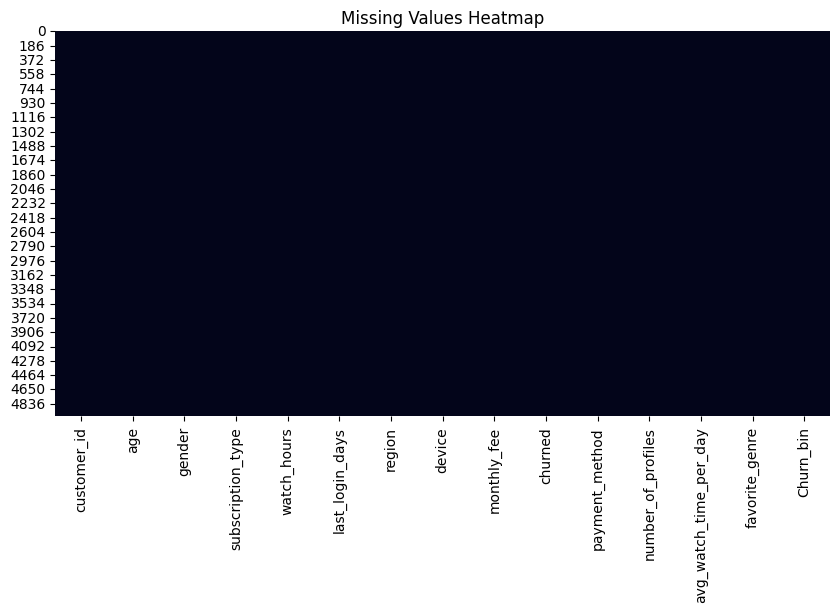

In [ ]:
missing = df.isnull().sum() / len(df) * 100
missing = missing[missing > 0].sort_values()

if not missing.empty:
    plt.figure(figsize=(8, 4))
    missing.plot(kind='barh', color='#e50914')
    plt.axvline(70, color='black', linestyle='--', label='70% threshold')
    plt.title('Figure 1. Missing Data by Column (%)')
    plt.xlabel('Missing %')
    plt.legend()
    plt.tight_layout()
    plt.savefig('fig1_missing.png', dpi=150)
    plt.show()
else:
    print("No missing values found in the DataFrame.")

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


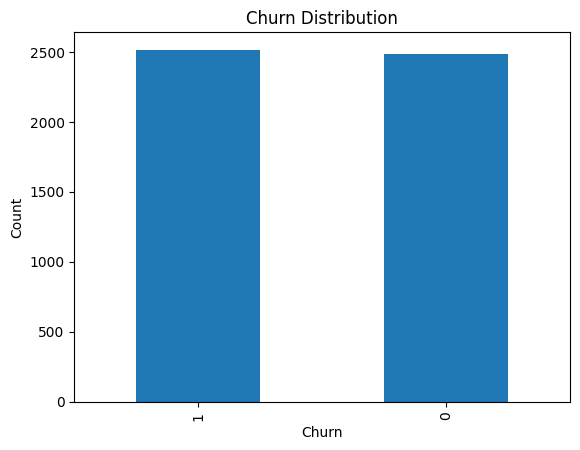

In [ ]:
df["churned"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

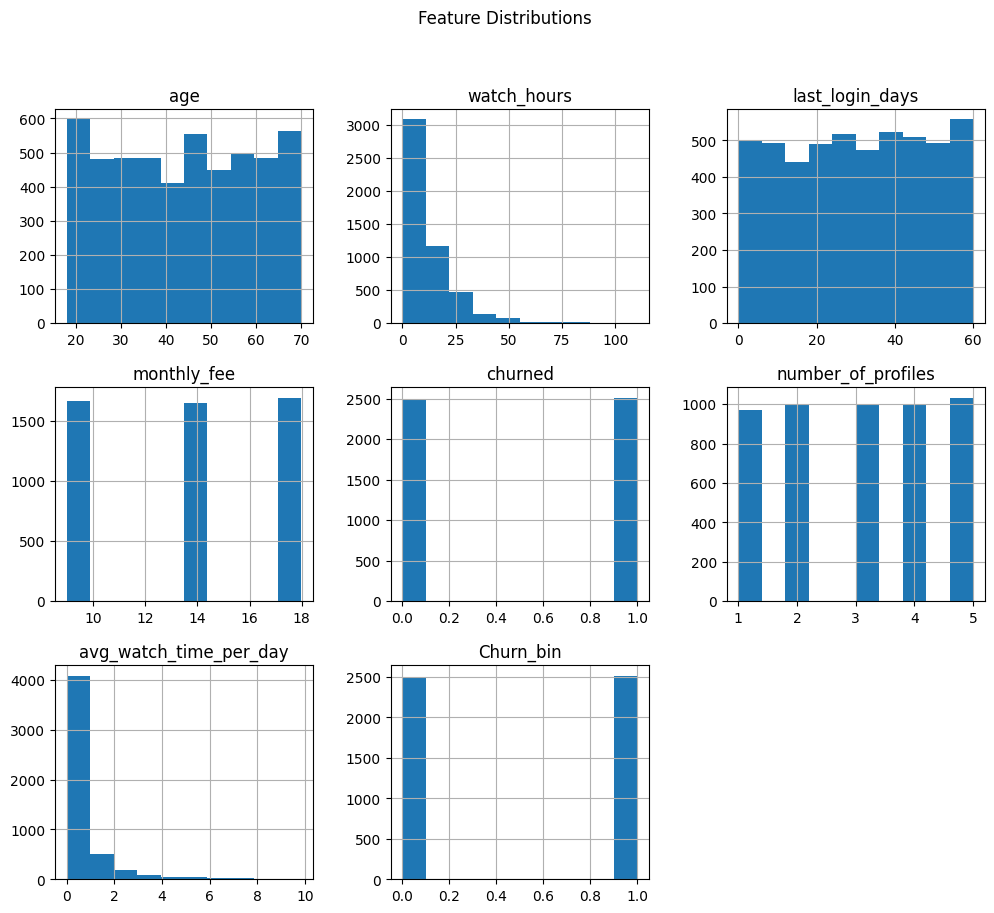

In [ ]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

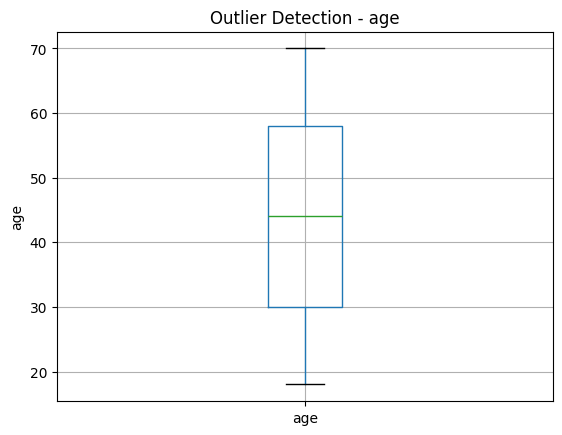

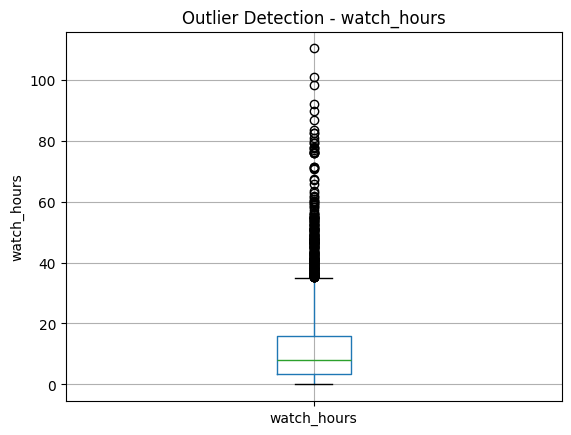

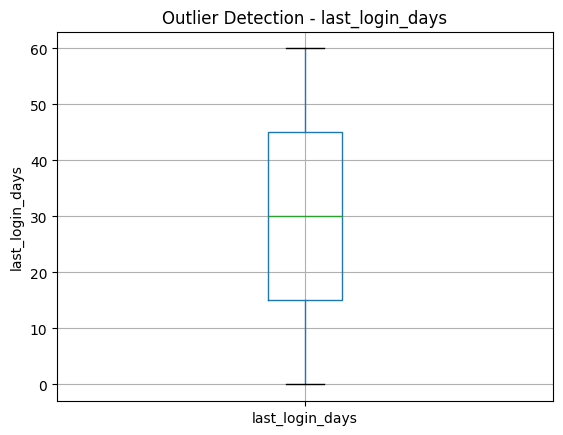

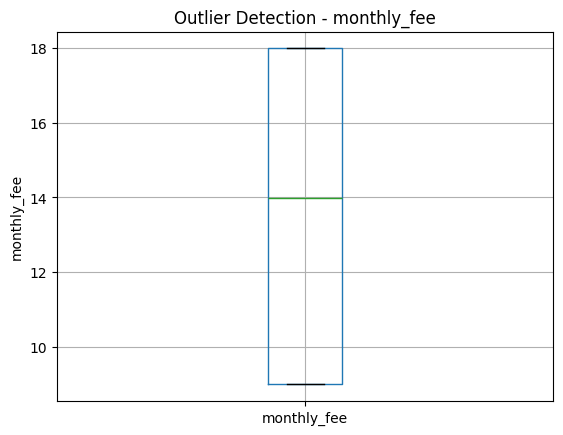

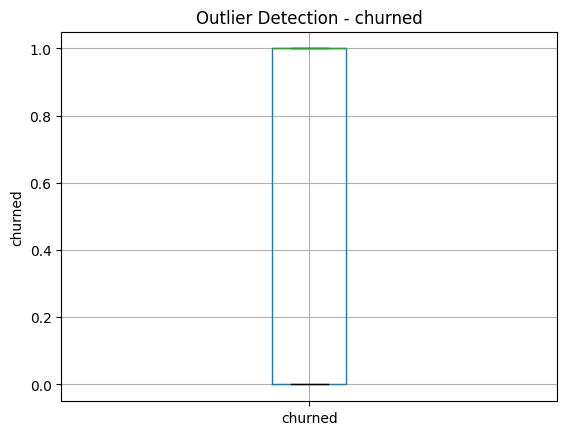

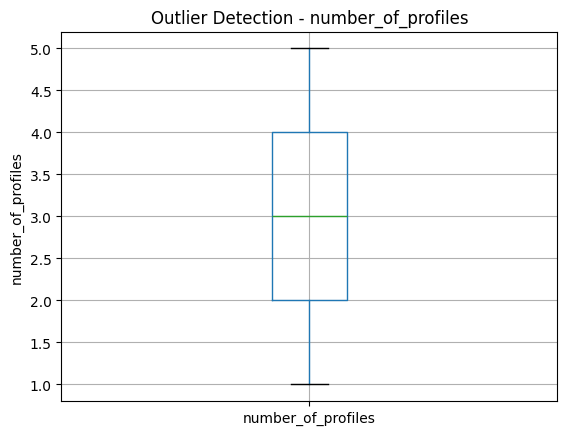

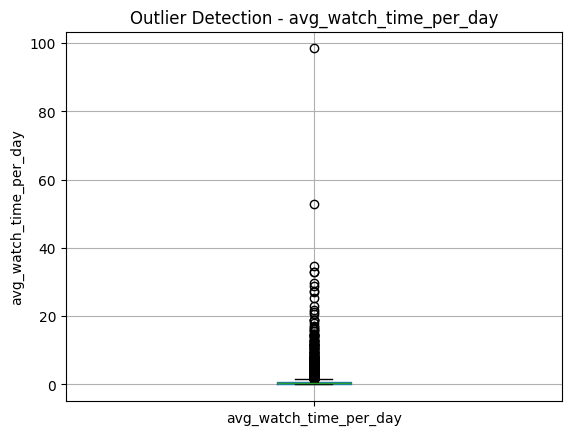

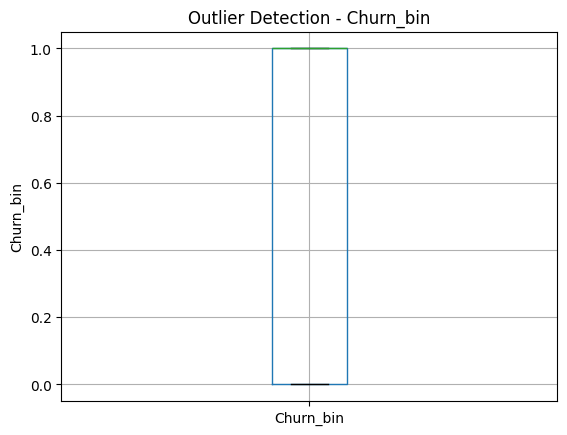

In [52]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in num_cols:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f"Outlier Detection - {col}")
    plt.ylabel(col)
    plt.show()

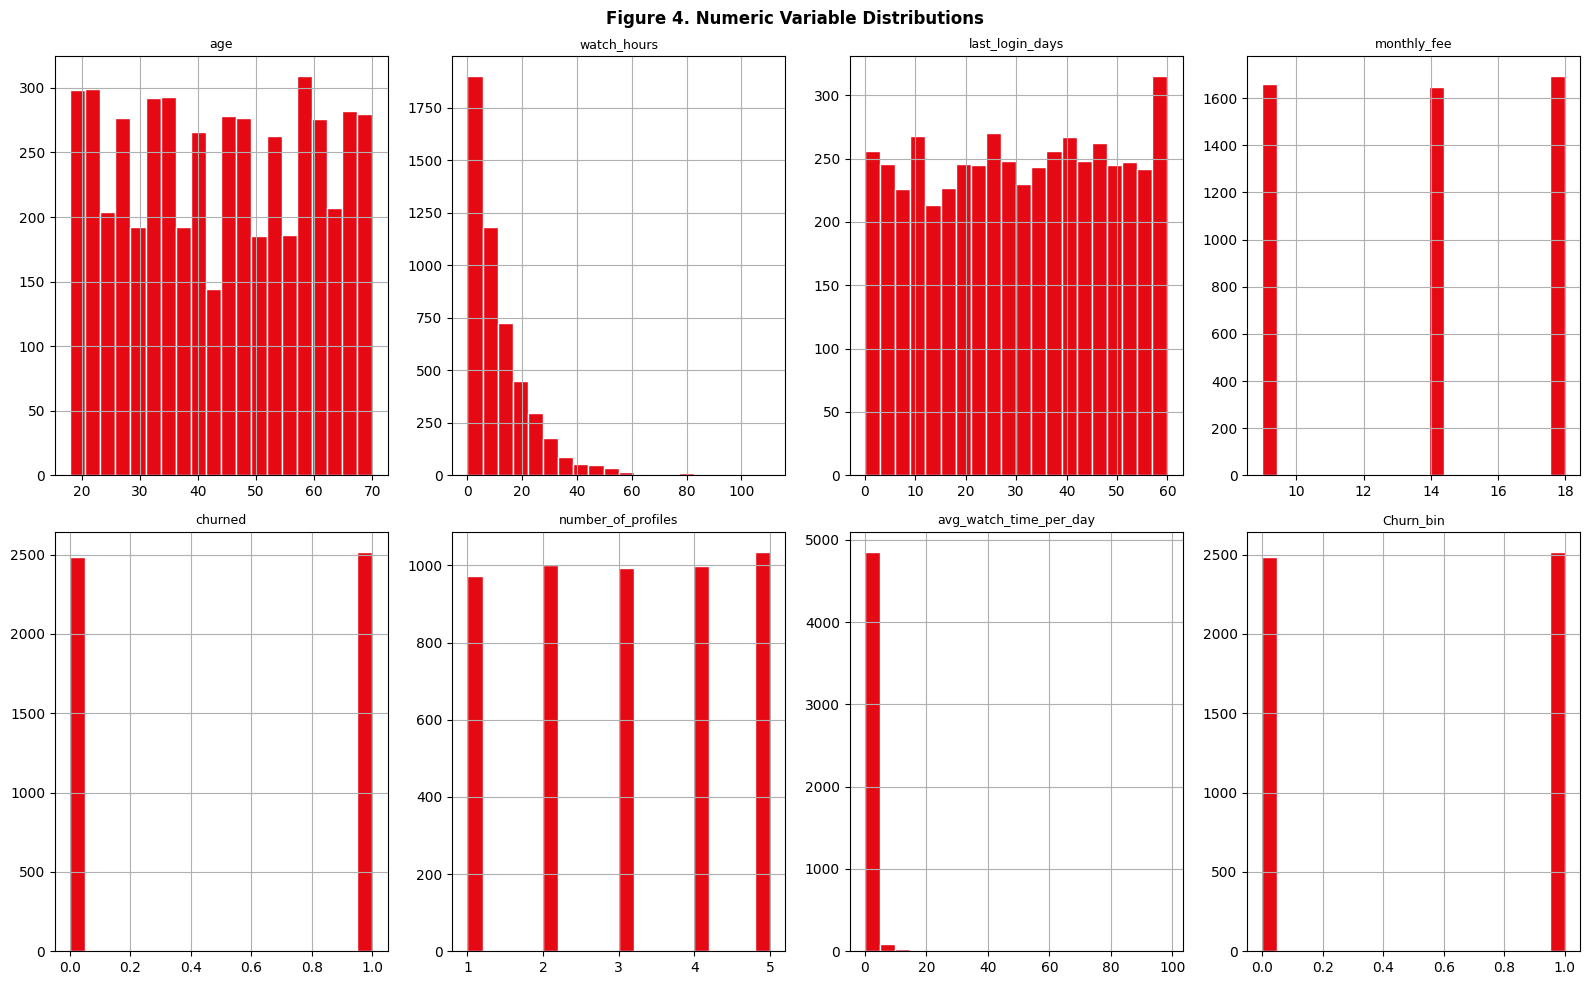

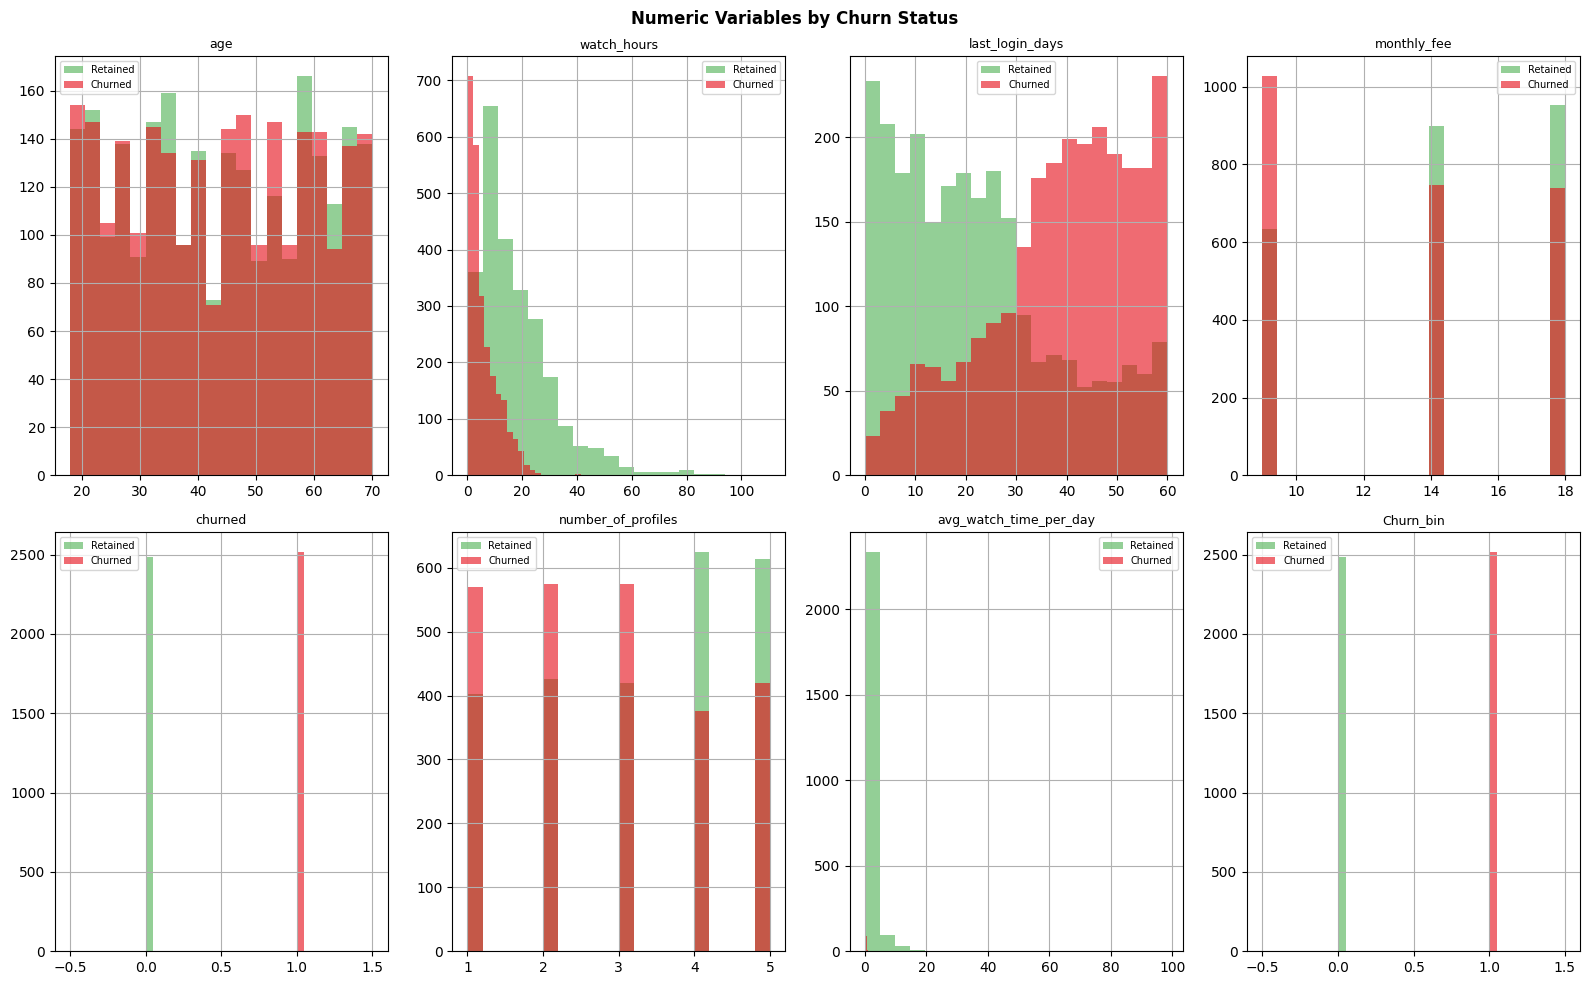

In [54]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 4, i+1)
    df[col].dropna().hist(bins=20, color='#e50914', edgecolor='white')
    plt.title(col, fontsize=9)
plt.suptitle('Figure 4. Numeric Variable Distributions', fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_histograms.png', dpi=150)
plt.show()


plt.figure(figsize=(16, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 4, i+1)
    df[df['Churn_bin']==0][col].dropna().hist(bins=20, alpha=0.6,
                                               color='#4caf50', label='Retained')
    df[df['Churn_bin']==1][col].dropna().hist(bins=20, alpha=0.6,
                                               color='#e50914', label='Churned')
    plt.title(col, fontsize=9)
    plt.legend(fontsize=7)
plt.suptitle('Numeric Variables by Churn Status', fontweight='bold')
plt.tight_layout()
plt.show()

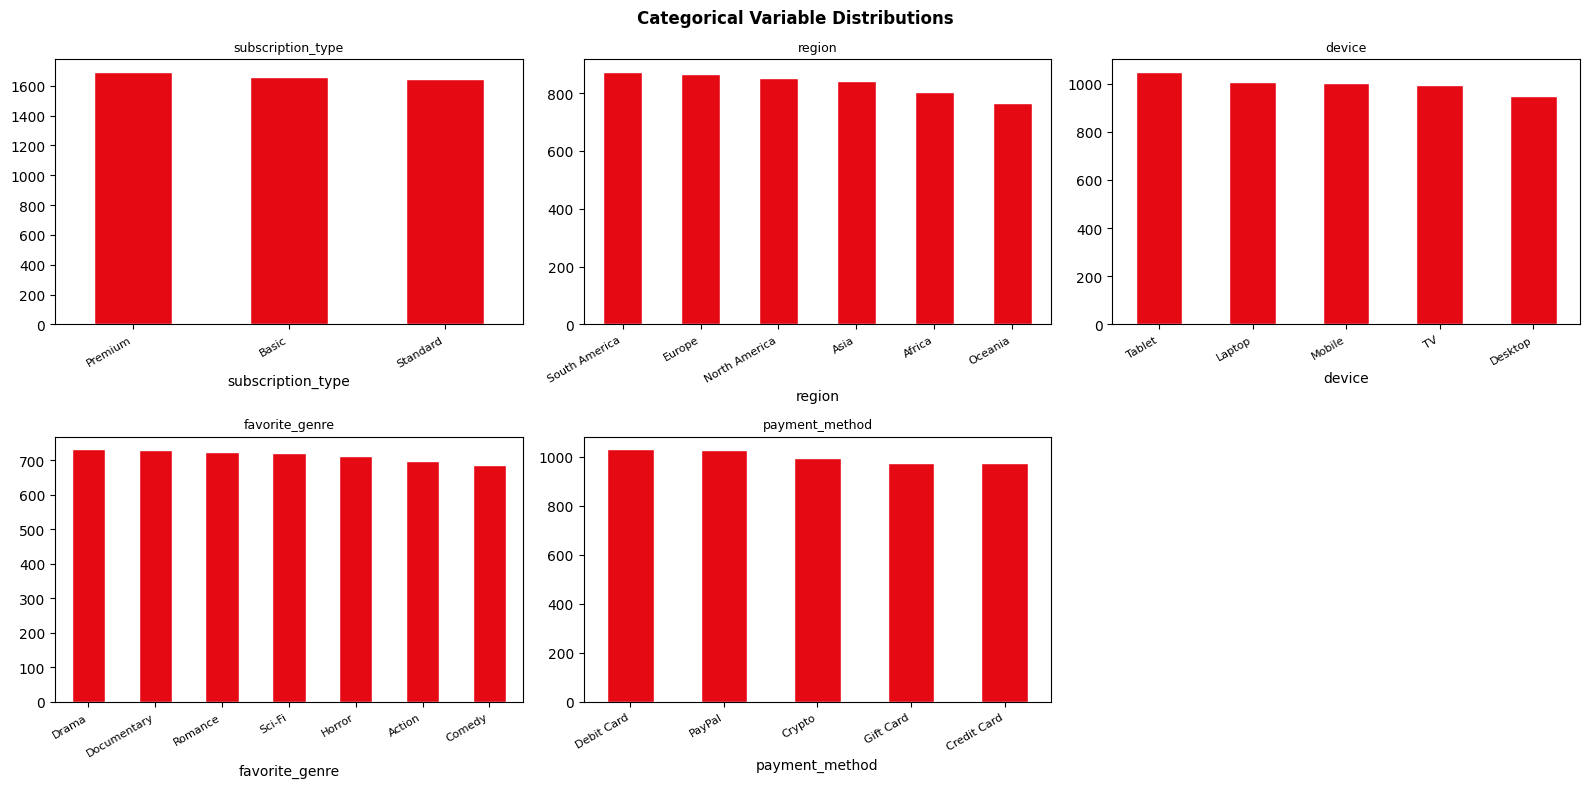

In [57]:
cat_cols = ['subscription_type', 'region', 'device',
            'favorite_genre', 'payment_method']

plt.figure(figsize=(16, 8))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    df[col].str.strip().value_counts().plot(kind='bar', color='#e50914',
                                             edgecolor='white')
    plt.title(col, fontsize=9)
    plt.xticks(rotation=30, ha='right', fontsize=8)
plt.suptitle('Categorical Variable Distributions', fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_categorical.png', dpi=150)
plt.show()

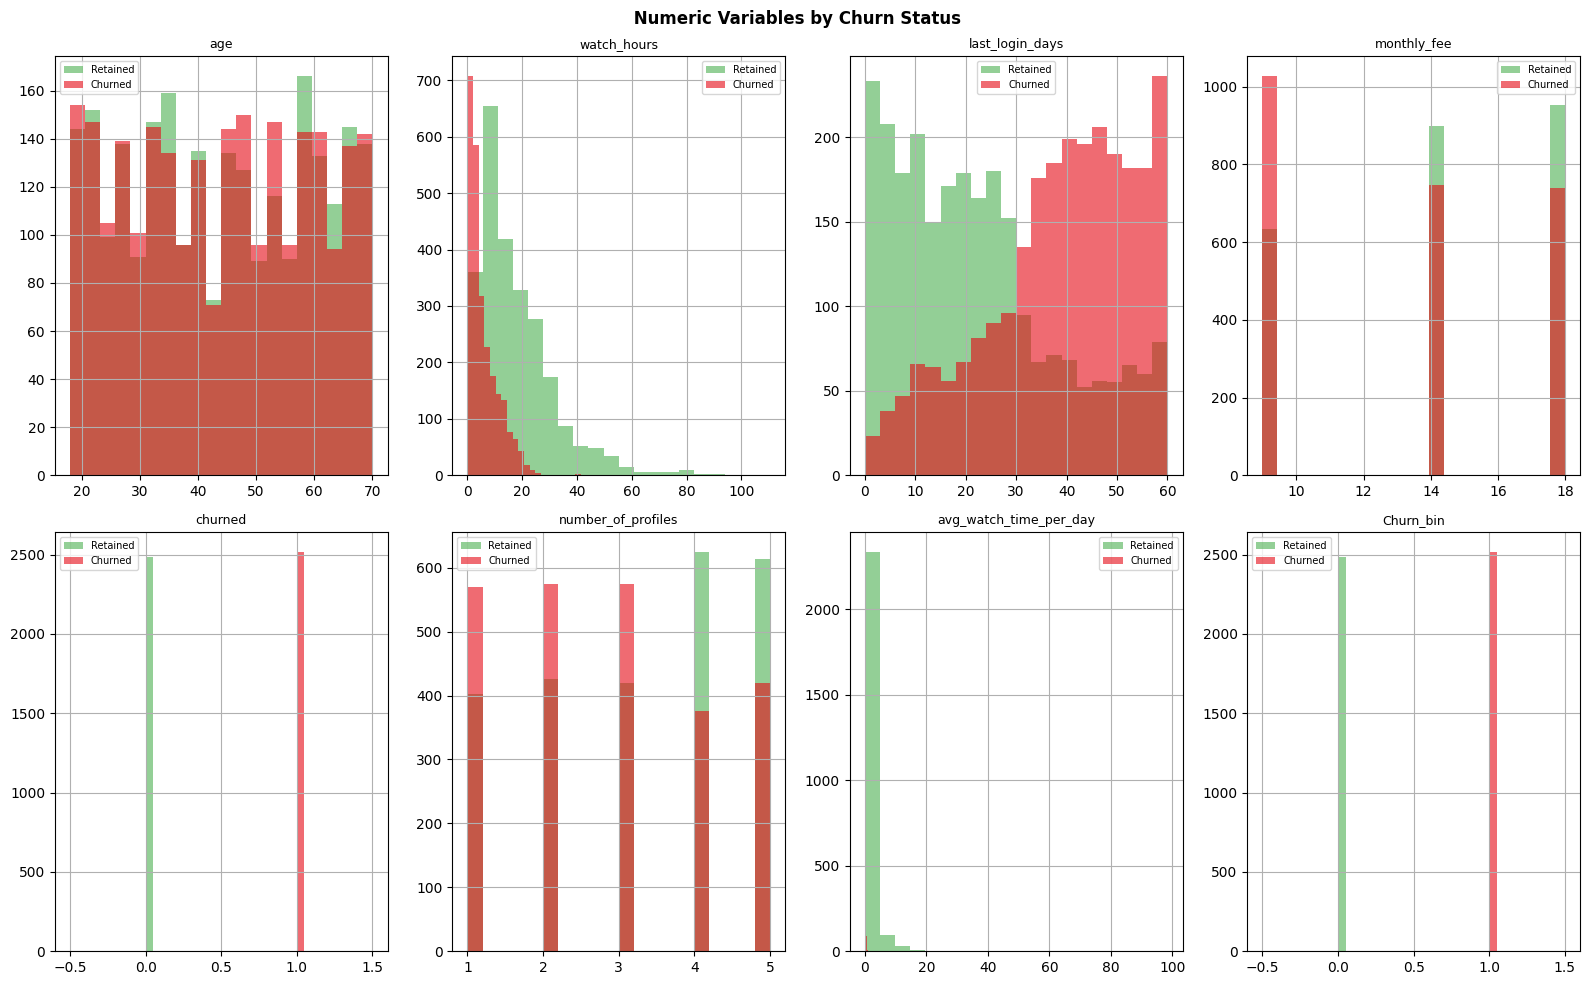

In [56]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 4, i+1)
    df[df['Churn_bin']==0][col].dropna().hist(bins=20, alpha=0.6,
                                               color='#4caf50', label='Retained')
    df[df['Churn_bin']==1][col].dropna().hist(bins=20, alpha=0.6,
                                               color='#e50914', label='Churned')
    plt.title(col, fontsize=9)
    plt.legend(fontsize=7)
plt.suptitle(' Numeric Variables by Churn Status', fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_numeric_vs_churn.png', dpi=150)
plt.show()

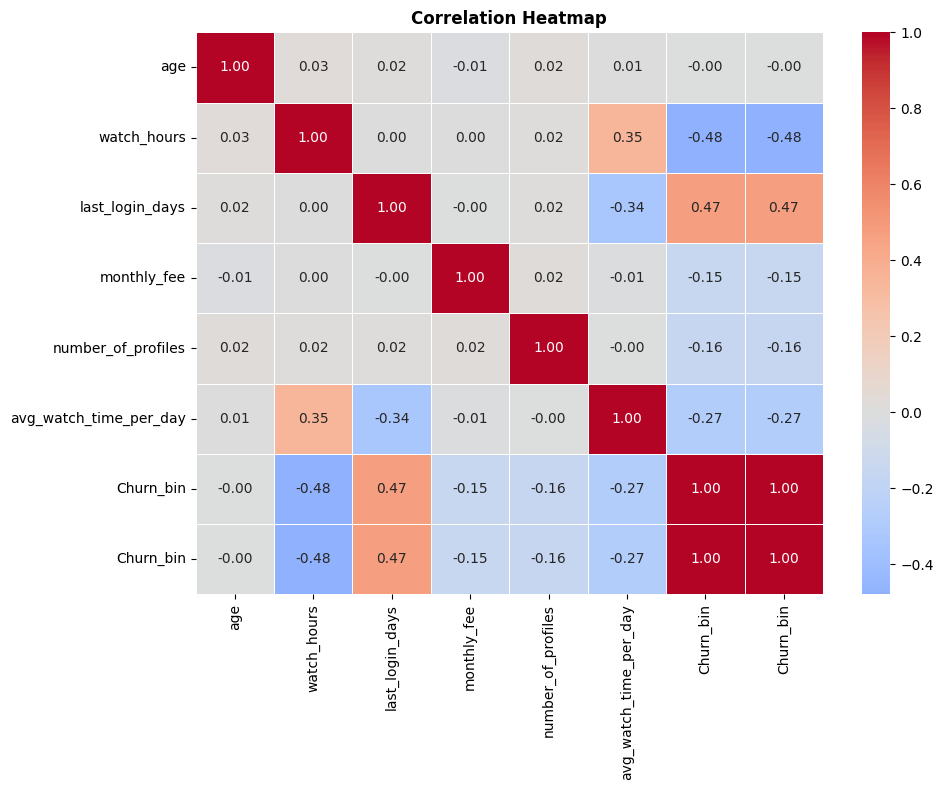

In [59]:
df['Churn_bin'] = df['churned']
le = LabelEncoder()
df_enc = df.copy()
for col in df_enc.select_dtypes('object').columns:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
df_enc['Churn_bin'] = df['Churn_bin']

# Redefine num_cols to ensure it contains the correct numeric feature column names
# Exclude 'customer_id' and 'churned' from the features as 'Churn_bin' is the target
num_cols = [col for col in df.select_dtypes(include=["int64", "float64"]).columns
            if col not in ['customer_id', 'churned']]

corr_cols = num_cols + [col for col in df_enc.select_dtypes('object').columns if col != 'customer_id'] + ['Churn_bin']

corr = df_enc[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_heatmap.png', dpi=150)
plt.show()

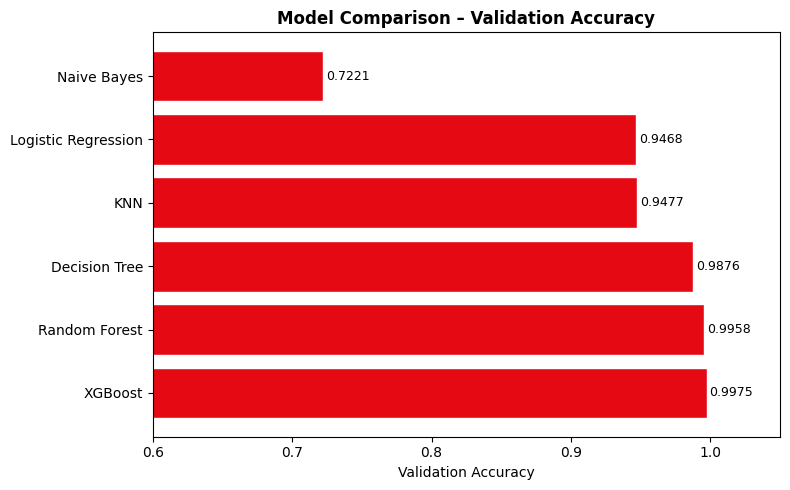

In [60]:
models  = ['XGBoost', 'Random Forest', 'Decision Tree',
           'KNN', 'Logistic Regression', 'Naive Bayes']
acc     = [0.9975, 0.9958, 0.9876, 0.9477, 0.9468, 0.7221]

plt.figure(figsize=(8, 5))
plt.barh(models, acc, color='#e50914', edgecolor='white')
plt.xlim(0.6, 1.05)
plt.xlabel('Validation Accuracy')
plt.title('Model Comparison – Validation Accuracy', fontweight='bold')
for i, v in enumerate(acc):
    plt.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig9_model_comparison.png', dpi=150)
plt.show()



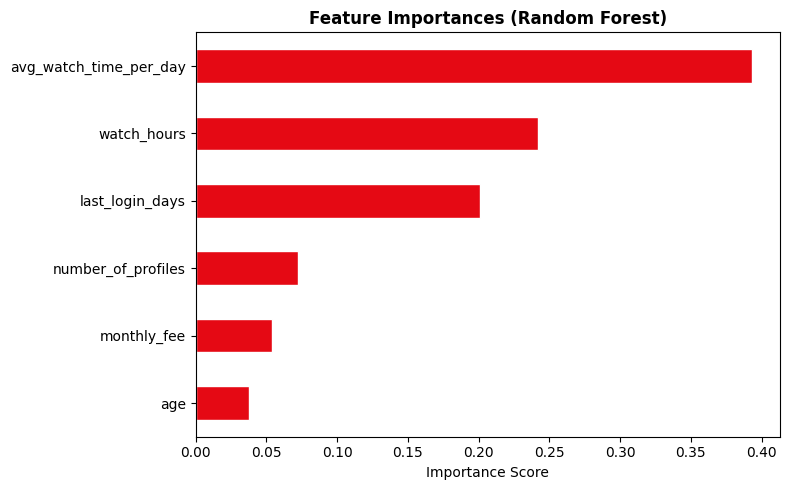

In [61]:
feature_cols = [c for c in corr_cols if c != 'Churn_bin']
X = df_enc[feature_cols].fillna(df_enc[feature_cols].median())
y = df_enc['Churn_bin']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                            stratify=y, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_tr, y_tr)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#e50914', edgecolor='white')
plt.title('Feature Importances (Random Forest)', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig10_importances.png', dpi=150)
plt.show()


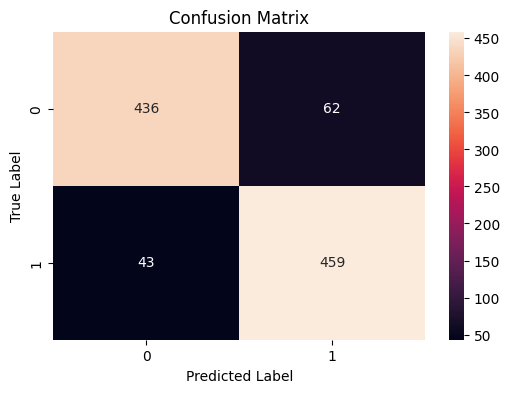


Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.88      0.89       498
           1       0.88      0.91      0.90       502

    accuracy                           0.90      1000
   macro avg       0.90      0.89      0.89      1000
weighted avg       0.90      0.90      0.89      1000


Accuracy: 0.895


In [ ]:
# remove ID column
X = df.drop(["customer_id","churned"], axis=1)

# target variable
y = df["churned"]
X = pd.get_dummies(X, drop_first=True)


# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# TRAIN MODEL
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


# MAKE PREDICTIONS
pred = model.predict(X_test)

# CONFUSION MATRIX
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# MODEL PERFORMANCE
print("\nClassification Report:\n")
print(classification_report(y_test, pred))

print("\nAccuracy:", accuracy_score(y_test, pred))
